# Global Superstore Dataset

# Introduction
This analysis investigates sales performance of GlobalMart, a global superstore. By analysing 4 years of sales data, I identify key actionable insights and recommendations for future marketing and sales approaches.

Business questions addressed include which markets contribute to highest sales, which categories are high-performing, as well as temporal and seasonal trends.

The dataset is the "[Global Superstore Dataset](./data/Global_Superstore.csv)". It is originally sourced from Kaggle but also included here for convenience. 

The project involves data import and cleaning, exploratory data analysis and statistical visualisations. The report of findings is attached in the same folder. This file serves as both a portfolio project and a guided analysis for other learners. 

[View final report here](./Report.pptx)

# Set Up

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Load Data

In [ ]:
df=pd.read_csv('../data/Global_Superstore.csv')
data=df.values

In [ ]:
df.head().T

,0,1,2,3,4
Row ID,40098,26341,25330,13524,47221
Order ID,CA-2014-AB10015140-41954,IN-2014-JR162107-41675,IN-2014-CR127307-41929,ES-2014-KM1637548-41667,SG-2014-RH9495111-41948
Order Date,11/11/2014,2/5/2014,10/17/2014,1/28/2014,11/5/2014
Ship Date,11/13/2014,2/7/2014,10/18/2014,1/30/2014,11/6/2014
Ship Mode,First Class,Second Class,First Class,First Class,Same Day
Customer ID,AB-100151402,JR-162107,CR-127307,KM-1637548,RH-9495111
Customer Name,Aaron Bergman,Justin Ritter,Craig Reiter,Katherine Murray,Rick Hansen
Segment,Consumer,Corporate,Consumer,Home Office,Consumer
Postal Code,73120.0,NaN,NaN,NaN,NaN
City,Oklahoma City,Wollongong,Brisbane,Berlin,Dakar


# Data Exploration

In [ ]:
df.shape

(1000, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,194.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,25079.328000,53966.170103,1710.971470,5.55800,0.092840,288.920440,272.384897
std,12897.726632,33734.306466,1259.239238,2.71846,0.148666,574.504782,176.160716
min,58.000000,2920.000000,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,15118.750000,19134.000000,826.907500,4.00000,0.000000,10.037500,209.827500
50%,25084.500000,60564.000000,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,34524.000000,88187.500000,2477.812500,7.00000,0.150000,518.872500,351.070250
max,51284.000000,98198.000000,9892.740000,14.00000,0.800000,4946.370000,923.630000


# Data Cleaning

In [ ]:
# check for missing values
df.isnull().sum()

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

In [ ]:
# handling missing data - in this case most rows do not have a postal code
df.drop(columns=["Postal Code"],inplace=True)

In [ ]:
# check consistency in category names
category_cols = ['Segment', 'Ship Mode', 'Region', 'Market', 'Order Priority']
for col in category_cols:
    print(df[col].unique())

['Consumer' 'Corporate' 'Home Office']
['First Class' 'Second Class' 'Same Day' 'Standard Class']
['Central US' 'Oceania' 'Western Europe' 'Western Africa' 'Western US'
 'Southern Asia' 'Western Asia' 'South America' 'Eastern Asia'
 'Southern Europe' 'Eastern Africa' 'Eastern Europe' 'Northern Europe'
 'Central America' 'Eastern US' 'Caribbean' 'Central Africa'
 'Southeastern Asia' 'Southern US' 'North Africa' 'Southern Africa'
 'Canada']
['USCA' 'Asia Pacific' 'Europe' 'Africa' 'LATAM']
['High' 'Critical' 'Medium' 'Low']


In [ ]:
# assign category columns to data type 'category' to save processing
for col in category_cols:
    df[col] = df[col].astype('category')

In [ ]:
# convert date objects to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Basic Analysis
#### Summary Calculations

In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"Total Sales: £{total_sales:.2f}")
print(f"Profit: £{total_profit:.2f}")

Total Sales: £1710971.47
Profit: £288920.44


#### Top-Selling Products

In [ ]:
# Calculate total quantity sold by product
top_products = df.groupby(['Product ID', 'Product Name', 'Category'])['Quantity'].sum().reset_index()

# Sort by Quantity sold
top_products.sort_values(by='Quantity', ascending=False).head(10)

,Product ID,Product Name,Category,Quantity
482,TEC-PH-3148,"Apple Smart Phone, Full Size",Technology,84
507,TEC-PH-5268,"Motorola Smart Phone, Full Size",Technology,84
495,TEC-PH-3806,"Cisco Smart Phone, Full Size",Technology,76
59,FUR-CH-4530,"Harbour Creations Executive Leather Armchair, ...",Furniture,58
523,TEC-PH-5839,"Samsung Smart Phone, Cordless",Technology,55
215,OFF-AP-4745,"Hoover Stove, White",Office Supplies,53
513,TEC-PH-5355,"Nokia Smart Phone, Full Size",Technology,52
525,TEC-PH-5841,"Samsung Smart Phone, VoIP",Technology,47
60,FUR-CH-4531,"Harbour Creations Executive Leather Armchair, ...",Furniture,46
213,OFF-AP-4743,"Hoover Stove, Red",Office Supplies,45


#### Analyze Sales by Region

In [ ]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(sales_by_region)

Region
Western Europe       259576.28
Oceania              220809.08
Southern Asia        205466.26
Eastern Asia         193590.60
Southeastern Asia    147337.60
Central America      140966.21
Northern Europe      103888.63
Southern Europe       94441.11
South America         64550.54
Eastern Europe        45662.19
Central Africa        33810.48
Western Asia          33308.21
Caribbean             30746.74
North Africa          26266.44
Southern Africa       22262.28
Eastern Africa        17387.94
Central US            17187.94
Western US            16729.95
Western Africa        15478.79
Eastern US            12256.44
Southern US            8360.75
Canada                  887.01
Name: Sales, dtype: float64


C:\Users\owild\AppData\Local\Temp\ipykernel_15812\2630671523.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)


In [ ]:
print(F'top_selling_regions: {sales_by_region.head()}')

top_selling_regions: Region
Western Europe       259576.28
Oceania              220809.08
Southern Asia        205466.26
Eastern Asia         193590.60
Southeastern Asia    147337.60
Name: Sales, dtype: float64


In [ ]:
correlation = df['Sales'].corr(df['Profit'])
print(f"The correlation between Sales and Profit is: {correlation:.2f}")

The correlation between Sales and Profit is: 0.53


# Data Visualization

### Sales by Product Category
Bar chart

Text(0.5, 1.0, 'Sales by Product Category')

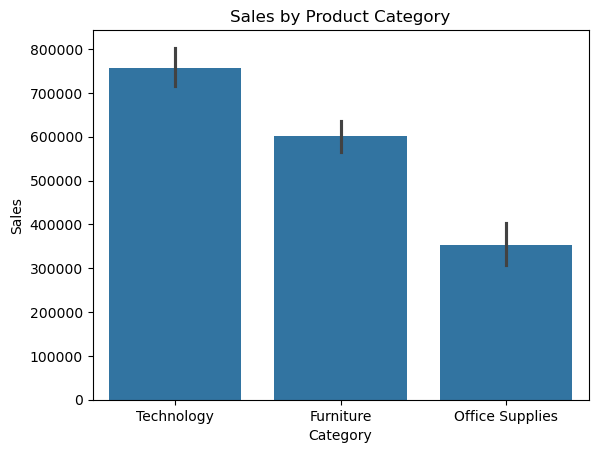

In [ ]:
sns.barplot(x='Category',y='Sales',data=df, estimator=sum)
plt.title('Sales by Product Category')

### Monthly Sales over Time
Line graph

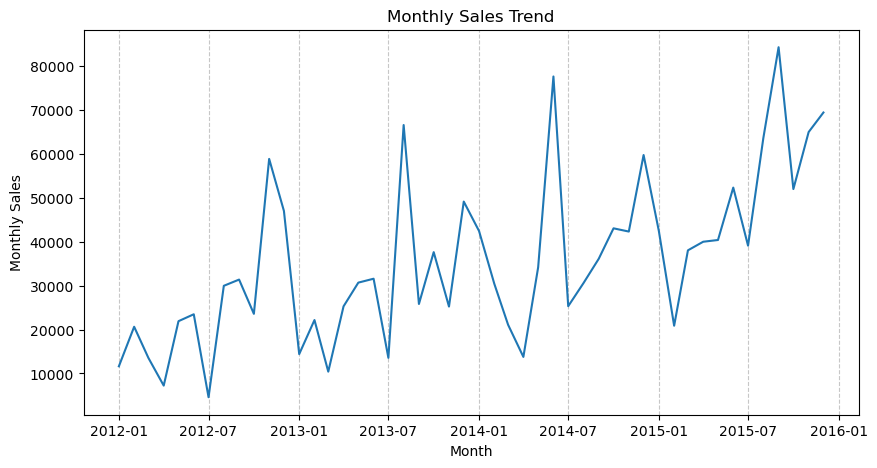

In [ ]:
# create a month column
df['Month'] = df['Order Date'].dt.to_period('M')
# calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.index=monthly_sales.index.to_timestamp()

# plot using Seaborn
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.ylabel('Monthly Sales')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Sales vs Profit
Scatter plot

Text(0, 0.5, 'Profit, £')

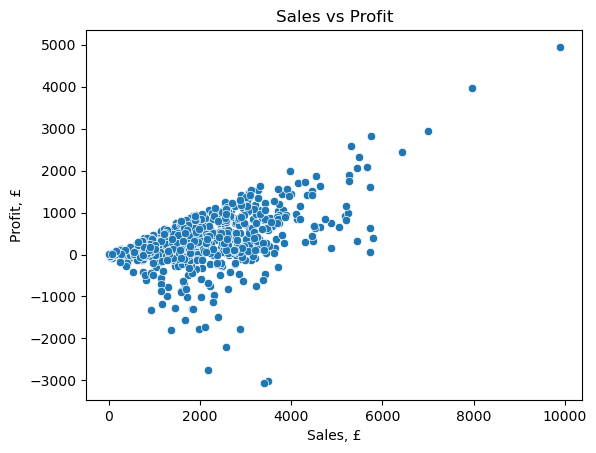

In [ ]:
# plot with Seaborn
sns.scatterplot(x='Sales',y='Profit',data=df)
plt.title('Sales vs Profit')
plt.xlabel('Sales, £')
plt.ylabel('Profit, £')

The correlation between Discount and Profit is: -0.51
Total discount: 92.84. Total profit: 288920.44


<Axes: xlabel='Discount', ylabel='Profit'>

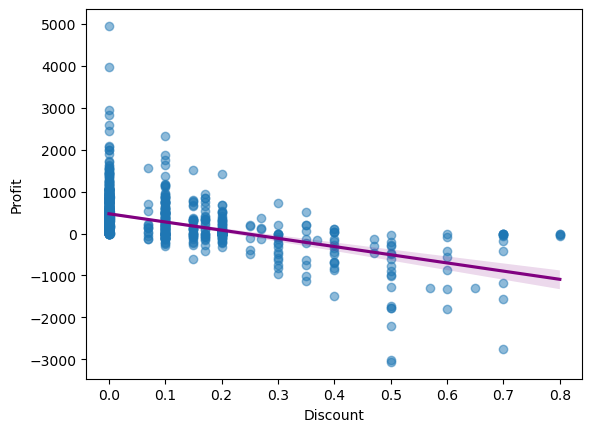

In [ ]:
# discount vs profit
total_discount = df['Discount'].sum()
total_profit = df['Profit'].sum()
discount_profit = df['Discount'].corr(df['Profit'])
print(f"The correlation between Discount and Profit is: {discount_profit:.2f}")
print(f'Total discount: {total_discount:.2f}. Total profit: {total_profit:.2f}')
sns.regplot(x='Discount',y='Profit',data=df,scatter_kws={'alpha':0.5},line_kws={'color':'purple'})

### Sales by Region and Product Category
Heat map

region on a map
category as colour
sales as point size

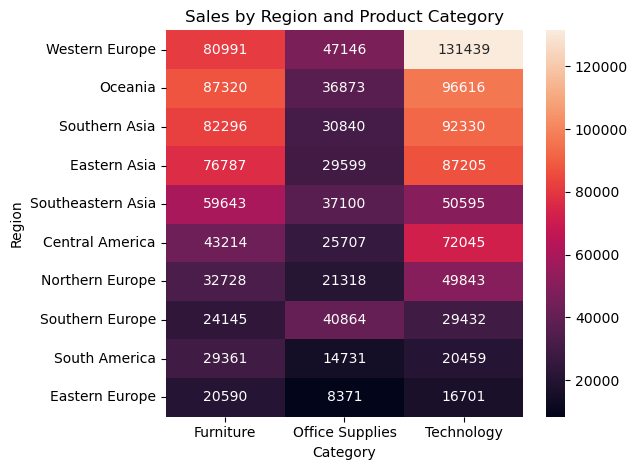

In [ ]:
heatmap_data=pd.crosstab(df['Region'],df['Category'],df['Sales'],aggfunc='sum')
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index].head(10)
sns.heatmap(heatmap_data, annot=True, fmt='.0f',cmap='rocket')
plt.title('Sales by Region and Product Category')
plt.tight_layout()

# Seasonal Time Series Analysis

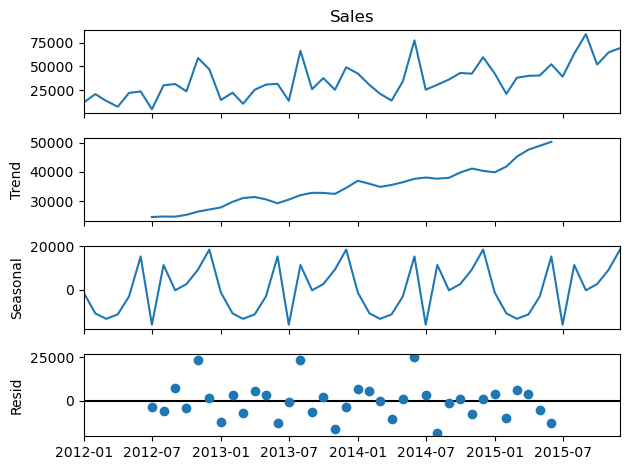

In [ ]:
seasonal = seasonal_decompose(monthly_sales,model='additive',period=12)
seasonal.plot(kind='line')
plt.show()